In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fno_definitions import*
import torch
import torch.fft

# Literature

1) FNO for differential equations
https://arxiv.org/abs/2010.08895

2) General introduction, complete
https://arxiv.org/abs/2512.01421v2, see NeuralOperator 2.0.0 library

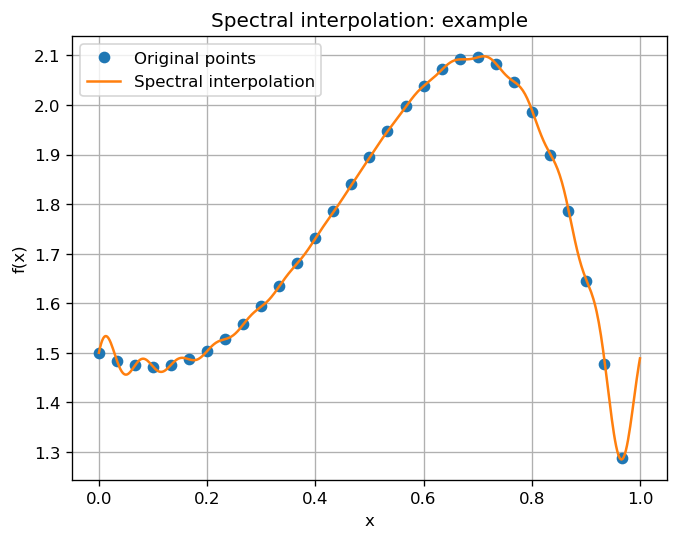

In [2]:
# test: spectral interpolation of 1d vector

def spectral_interpolation(signal: torch.tensor, M: int) -> torch.Tensor:

    """Gives the spectral interpolation of a 1d array on M points. Following 2), page 16"""
    N = len(signal) 
    fft_coeffs = torch.fft.fft(signal)
    pos_freqs = fft_coeffs[:N//2 + 1]
    neg_freqs = fft_coeffs[N//2 + 1:]

    fft_coeffs_padded = torch.cat([pos_freqs, torch.zeros(M - N), neg_freqs])

    return (torch.fft.ifft(fft_coeffs_padded).real)*M/N # the interpolated signal, scale by M/N to preserve energy


f = lambda x: torch.sin(3*x**2) + 0.5*torch.cos(torch.sqrt(x)) + 1.0 - x/3.

N = 30
xx = torch.linspace(0, 1, N+1)[:-1] # data x_n, n from 0 to N-1 

M_eval = 500

plt.figure(dpi = 120)
plt.title('Spectral interpolation: example')
plt.grid()
plt.xlabel('x')
plt.ylabel('f(х)')
plt.plot(xx, f(xx), 'o', label = 'Original points')
plt.plot(torch.linspace(0, 1, M_eval), spectral_interpolation(f(xx), M_eval), label = 'Spectral interpolation')
plt.legend()
plt.show()

In [ ]:
# notes for later

def spectral_differentiation(signal:torch.tensor)->torch.tensor:

    # TO DO

    return 0


from neuralop.models import FNO

operator = FNO(n_modes=(64, 64),
               hidden_channels=64,
               in_channels=2,
               out_channels=1)